In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mysql.connector
warnings.filterwarnings('ignore')

In [2]:
import mysql.connector

conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="",
    database="genz_erd"
)

query = """
SELECT 
    u.age,
    g.gender_name AS gender,
    c.country_name AS country,
    us.daily_usage_hours,
    p.platform_name AS primary_platform,
    us.num_platforms_used,
    up.purpose_name AS purpose,
    us.avg_session_minutes,
    hb.night_usage,
    hb.mental_health_score,
    al.level_name AS addiction_level,
    hb.screen_time_before_sleep
FROM user u
JOIN gender g ON u.gender_id = g.gender_id
JOIN country c ON u.country_id = c.country_id
JOIN user_session us ON u.user_id = us.user_id
JOIN platform p ON us.platform_id = p.platform_id
JOIN usage_purpose up ON us.purpose_id = up.purpose_id
JOIN health_behavior hb ON u.user_id = hb.user_id
JOIN addiction_level al ON hb.level_id = al.level_id
LIMIT 5000
"""

df = pd.read_sql(query, conn)
df.head(5)

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.65862,Snapchat,4,Education,29.2224,0,6.70583,Medium,15.779400
1,19,Male,Australia,2.65862,Snapchat,4,Education,29.2224,0,8.79987,Medium,33.309300
2,19,Male,Australia,2.65862,Snapchat,4,Education,29.2224,1,7.60524,Medium,0.478019
3,19,Male,Australia,2.65862,Snapchat,4,Education,29.2224,1,8.61386,Medium,39.395900
4,19,Male,Australia,2.65862,Snapchat,4,Education,29.2224,1,6.92232,Medium,35.350800


In [3]:
df.info()
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   int64  
 1   gender                    5000 non-null   str    
 2   country                   5000 non-null   str    
 3   daily_usage_hours         5000 non-null   float64
 4   primary_platform          5000 non-null   str    
 5   num_platforms_used        5000 non-null   int64  
 6   purpose                   5000 non-null   str    
 7   avg_session_minutes       5000 non-null   float64
 8   night_usage               5000 non-null   int64  
 9   mental_health_score       5000 non-null   float64
 10  addiction_level           5000 non-null   str    
 11  screen_time_before_sleep  5000 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 468.9 KB
(5000, 12)


In [4]:
df.columns

Index(['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform',
       'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage',
       'mental_health_score', 'addiction_level', 'screen_time_before_sleep'],
      dtype='str')

In [5]:
df.describe()

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,5000.0,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.0,3.570565,2.59500,24.775276,0.614400,7.031788,39.309556
std,0.0,1.242547,1.34957,7.332343,0.486785,1.020071,20.068821
min,19.0,1.313170,1.00000,9.248150,0.000000,4.207120,0.000000
25%,19.0,2.600850,1.00000,20.769200,0.000000,6.349030,25.848400
50%,19.0,3.885550,2.00000,24.184800,1.000000,7.037490,38.815000
75%,19.0,4.568140,3.00000,29.935400,1.000000,7.781460,50.989200
max,19.0,5.534710,5.00000,38.653000,1.000000,10.000000,106.229000


In [6]:
print(f'there are {df.duplicated().sum()} duplicated values in the dataset')
print(f'there are {df.isnull().sum()} null values in the dataset')

there are 0 duplicated values in the dataset
there are age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64 null values in the dataset


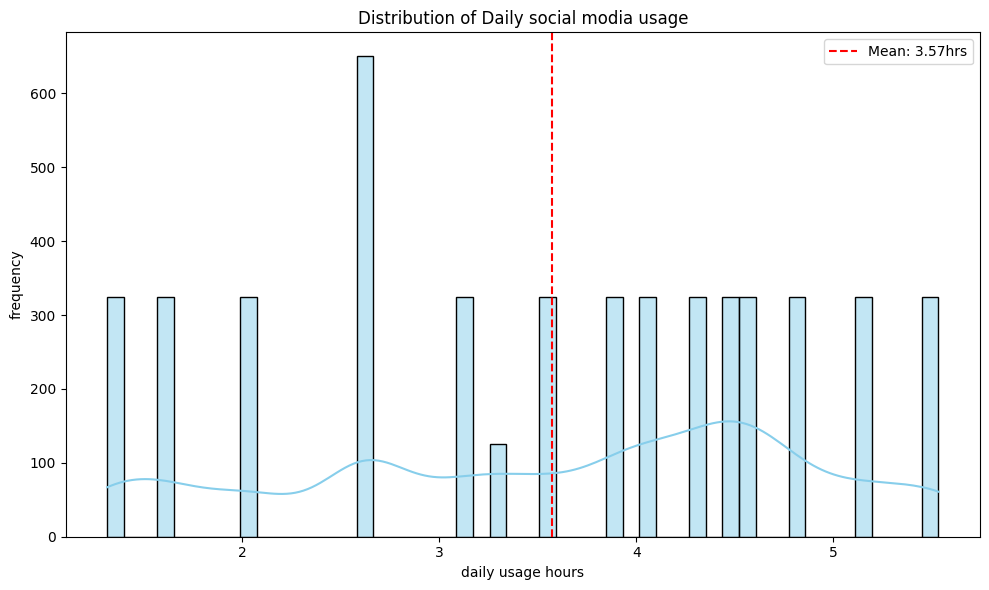

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['daily_usage_hours'],bins=50,kde=True,color='skyblue',edgecolor='black')
plt.title('Distribution of Daily social modia usage')
plt.xlabel('daily usage hours')
plt.ylabel('frequency')
plt.axvline(df['daily_usage_hours'].mean(), color='red', linestyle='--', label=f"Mean: {df['daily_usage_hours'].mean():.2f}hrs")
plt.legend()
plt.tight_layout()
plt.show()

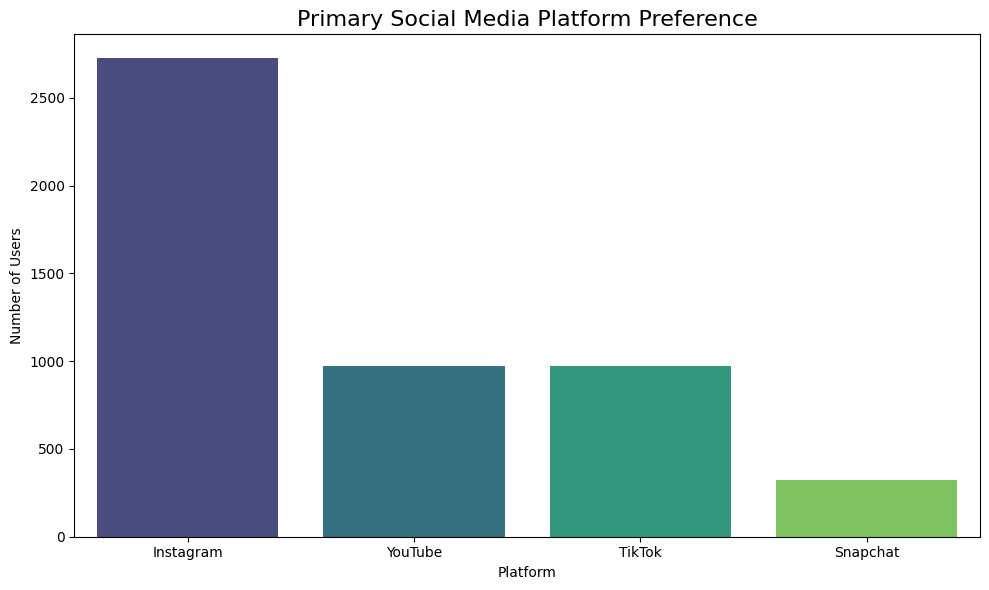


 Instagram as highest amount of GenZ


In [8]:
plt.figure(figsize=(10,6))
platform_order = df['primary_platform'].value_counts().index
sns.countplot(data=df,x='primary_platform',order=platform_order,palette='viridis')
plt.title('Primary Social Media Platform Preference', fontsize=16)
plt.xlabel('Platform')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()
print('\n Instagram as highest amount of GenZ')

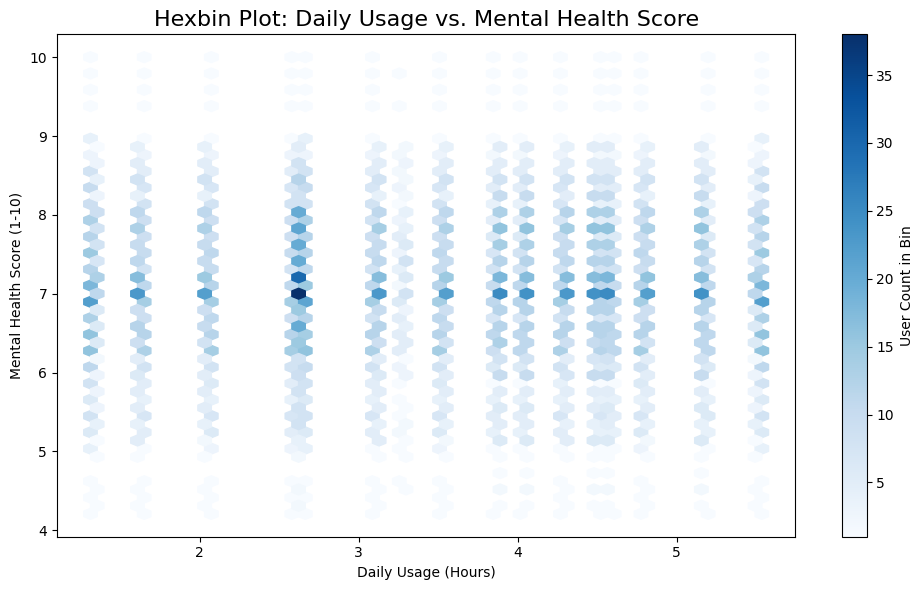

In [9]:
plt.figure(figsize=(10,6))
plt.hexbin(df['daily_usage_hours'],df['mental_health_score'],gridsize=50,cmap='Blues',mincnt=1)
plt.colorbar(label='User Count in Bin')
plt.title('Hexbin Plot: Daily Usage vs. Mental Health Score', fontsize=16)
plt.xlabel('Daily Usage (Hours)')
plt.ylabel('Mental Health Score (1-10)')
plt.tight_layout()
plt.show()

In [10]:
plt.figure(figsize=(10,6))
addiction_gender = pd.crosstab(df['gender'],df['addiction_level'],normalize='index') * 100
addiction_gender

addiction_level,Medium
gender,
Male,100.0


<Figure size 1000x600 with 0 Axes>

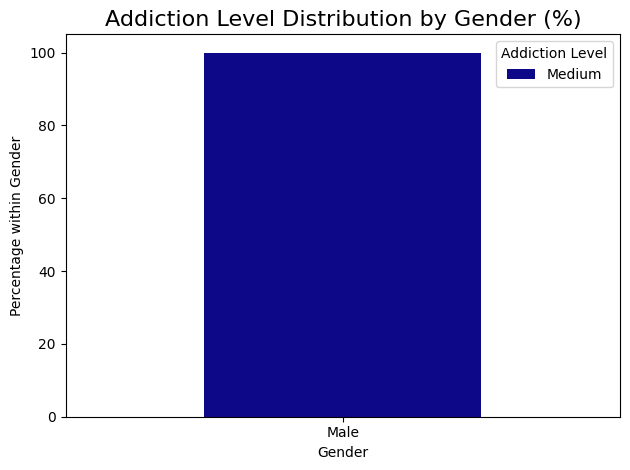

In [11]:
addiction_gender.plot(kind='bar',stacked=True,colormap='plasma')
plt.title('Addiction Level Distribution by Gender (%)', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Percentage within Gender')
plt.xticks(rotation=0)
plt.legend(title='Addiction Level')
plt.tight_layout()
plt.show()

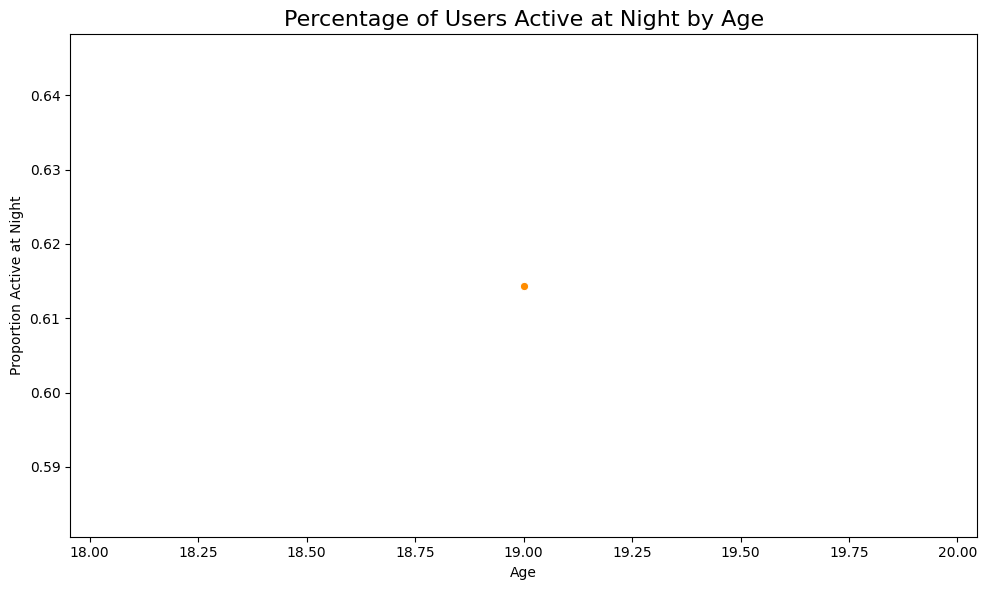

In [12]:
plt.figure(figsize=(10,6))
night_usage_by_age = df.groupby('age')['night_usage'].mean()
sns.lineplot(x=night_usage_by_age.index,y=night_usage_by_age.values,marker='o',color='darkorange')
plt.title('Percentage of Users Active at Night by Age', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Proportion Active at Night')
plt.tight_layout()
plt.show()

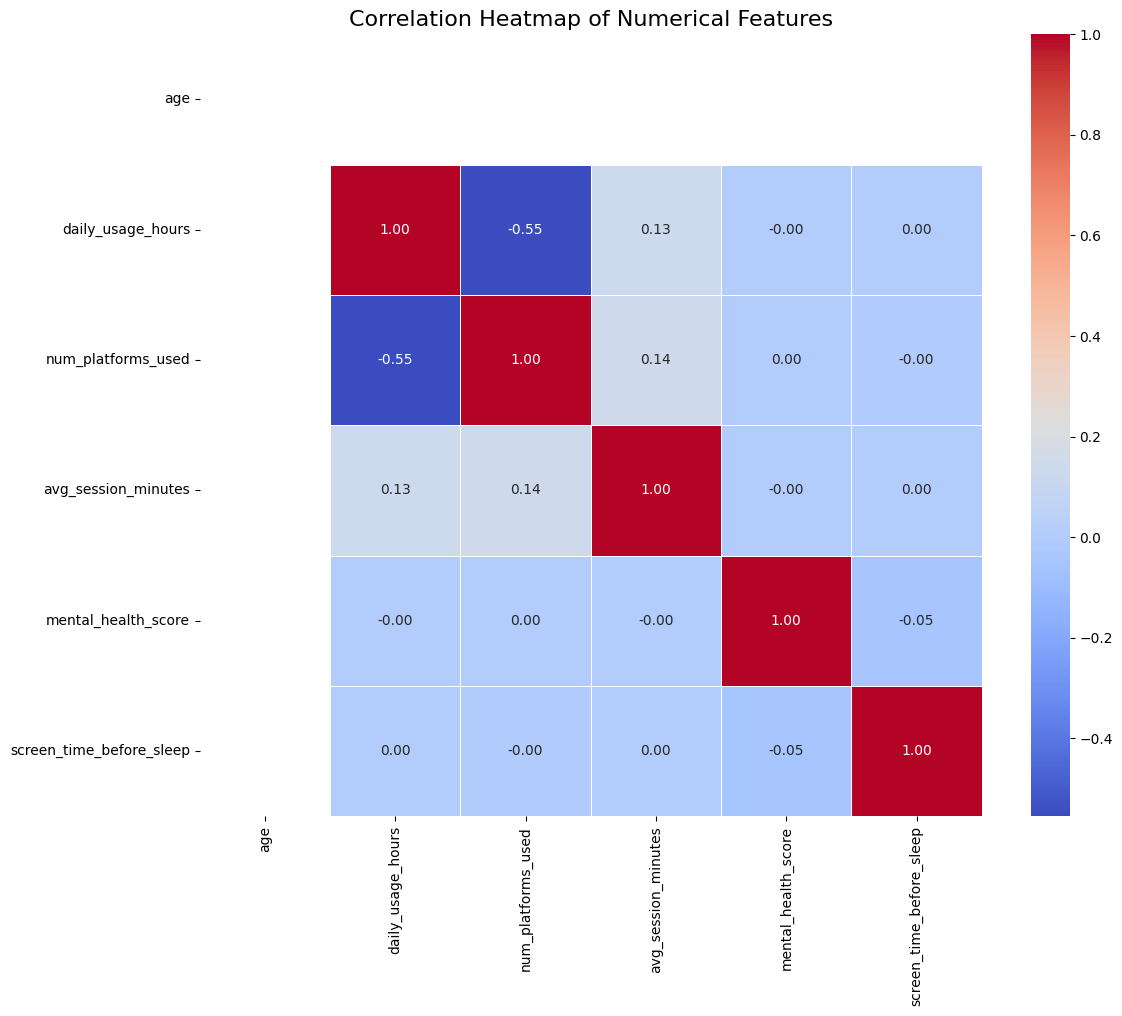

In [13]:
numerical_cols = ['age', 'daily_usage_hours', 'num_platforms_used',
                  'avg_session_minutes', 'mental_health_score',
                  'screen_time_before_sleep']

plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

ordinal_cols = ['addiction_level']
ord_en = OrdinalEncoder()
df[ordinal_cols] = ord_en.fit_transform(df[ordinal_cols])

nominal_cols = ['gender', 'country','primary_platform','purpose']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

scaler = MinMaxScaler()
numerical_cols = ['age','num_platforms_used','daily_usage_hours','avg_session_minutes','night_usage',
                  'mental_health_score','screen_time_before_sleep']
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

df_encoded.head(5)

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep,primary_platform_Snapchat,primary_platform_TikTok,primary_platform_YouTube,purpose_Socializing
0,0.0,0.318711,0.75,0.679284,0.0,0.431342,0.0,0.148541,1,0,0,0
1,0.0,0.318711,0.75,0.679284,0.0,0.792827,0.0,0.313561,1,0,0,0
2,0.0,0.318711,0.75,0.679284,1.0,0.586603,0.0,0.004500,1,0,0,0
3,0.0,0.318711,0.75,0.679284,1.0,0.760717,0.0,0.370858,1,0,0,0
4,0.0,0.318711,0.75,0.679284,1.0,0.468713,0.0,0.332779,1,0,0,0


Model                          | MAE        | RMSE       | R2 Score  
---------------------------------------------------------------------------
Linear Regression              | 0.0000     | 0.0000     | 1.0000    
Ridge Regression               | 0.0000     | 0.0000     | 1.0000    
Lasso Regression               | 0.0000     | 0.0000     | 1.0000    
Random Forest                  | 0.0000     | 0.0000     | 1.0000    
Gradient Boosting              | 0.0000     | 0.0000     | 1.0000    
XGBoost                        | 0.0000     | 0.0000     | 1.0000    


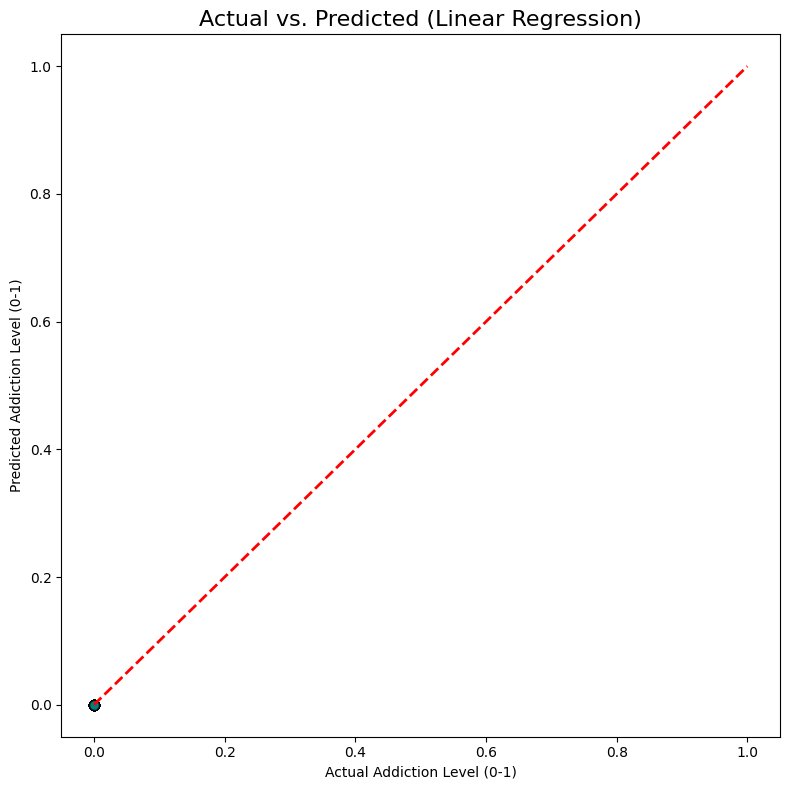

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#models
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

#spliting the target column 
X = df_encoded.drop('addiction_level',axis=1)
y = df_encoded['addiction_level']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#adding the model 

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='rmse')
}

results = {}

print(f"{'Model':<30} | {'MAE':<10} | {'RMSE':<10} | {'R2 Score':<10}")
print("-"*75)

for name,model in models.items():
    #training
    model.fit(X_train,y_train)

    #predicting
    y_pred = model.predict(X_test)

    #evaluation
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    r2 = r2_score(y_test,y_pred)

    #storing results
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Predictions': y_pred
    }

    print(f"{name:<30} | {mae:<10.4f} | {rmse:<10.4f} | {r2:<10.4f}")


best_model = max(results,key = lambda k: results[k]['R2'])


plt.figure(figsize=(8, 8))
y_true = y_test.values
y_pred_best = results[best_model]['Predictions']

plt.scatter(y_true, y_pred_best, alpha=0.5, color='teal', edgecolors='k', s=50)
plt.plot([0, 1], [0, 1], 'r--', lw=2) 
plt.title(f'Actual vs. Predicted ({best_model})', fontsize=16)
plt.xlabel('Actual Addiction Level (0-1)')
plt.ylabel('Predicted Addiction Level (0-1)')
plt.tight_layout()
plt.show()

In [16]:
query = "SELECT * FROM genz_erd.gender"
df_test = pd.read_sql(query, conn)
print(df_test)

   gender_id   gender_name
0          1          Male
1          2        Female
2          3         Other
3          4  Abang Fachri
